## Preparación y Limpieza de los Datos

Antes de comenzar con el análisis de clustering, debemos preparar los datos según las instrucciones y las conclusiones obtenidas en el análisis PCA previo. Esto incluye eliminar las columnas categóricas finales, lidiar con los valores nulos (`NA`) y eliminar los registros anómalos (valores negativos en contaminantes).

# Ejercicio 1.1
---

## ¿Cuál es el valor de K más apropiado y por qué?**
De acuerdo al gráfico del Método del Codo generado previamente en el ejemplo del curso, el valor más apropiado es **K = 3**.
Esta decisión se justifica matemáticamente porque en K=3 se observa el "codo" o punto de inflexión en la curva. La Suma de Cuadrados Intra-Cluster (SSW) cae drásticamente al pasar de 1 a 3 grupos, pero a partir de K=4 la reducción del error se vuelve mínima. Agregar un cuarto grupo no aporta una mejora significativa, por lo que 3 es el modelo óptimo.

---

# Ejecicio 1.2
---

## Caracterización e interpretación de los grupos obtenidos:**
Al analizar los datos morfológicos de las semillas (como área y perímetro) agrupados en 3 clusters, se pueden caracterizar las tres variedades de trigo de la siguiente manera:
* **Grupo 1:** Semillas de tamaño intermedio (valores medios en área y perímetro).
* **Grupo 2:** Semillas más pequeñas y compactas del conjunto.
* **Grupo 3:** Semillas significativamente más grandes y de mayor área.

En conclusión, el algoritmo logró separar perfectamente las 3 variedades reales de trigo basándose únicamente en sus medidas geométricas.

# Ejercicio 2.1

---

## Descripción de los datos y pertinencia del agrupamiento

**Descripción de los datos:**
| Variable | Descripción | Tipo de Dato | Escala / Magnitud |
| :--- | :--- | :--- | :--- |
| **`pm25`** | Concentración de material particulado fino en el aire. | Numérica (Continua) | **Alta** (Valores aprox. entre 0 y \>130) |
| **`no2`** | Concentración de Dióxido de Nitrógeno en el aire. | Numérica (Continua) | **Alta** (Valores aprox. entre 0 y \>170) |
| **`trafico`** | Nivel de flujo o carga vehicular en el sector. | Numérica (Continua) | **Alta** (Valores aprox. entre 1 y \>199) |
| **`viento`** | Velocidad del viento registrada. | Numérica (Continua) | **Baja** (Valores aprox. entre 0 y 7) |

En el análisis de Componentes Principales (PCA) previo, descubrimos que **no existe una alta correlación** entre estas variables, lo que provocó que el PCA no fuera efectivo para reducir la dimensionalidad.

¿Invalida esto el uso de clustering? **No, al contrario.**
La baja correlación significa que cada variable aporta información única e independiente. El análisis de agrupamiento (Clustering) es altamente pertinente aquí porque nos permitirá descubrir **"perfiles" o "tipologías"** de observaciones ocultas en los datos espaciales/temporales.

---

# Ejercicio 2.2

---

## Cálculo del Clustering y K óptimo

Para determinar el número óptimo de grupos ($k$), utilizaremos dos métricas tradicionales: el **Método del Codo (WSS - Within-Cluster Sum of Square)** y el **Estadístico Gap**.

In [ ]:
# Carga de datos
datos_originales <- read.csv("/home/Grupo4.csv", sep=";", dec=".", header=TRUE)

# Extraer todas las columnas salvo las dos ultimas (contaminacion y alerta)
datos_cluster <- datos_originales[, 1:(ncol(datos_originales)-2)]

# Eliminar filas con valores nulos (NA)
datos_cluster <- na.omit(datos_cluster)

# Filtrar valores físicos imposibles (menores a cero) según sugerencia del PCA
datos_cluster <- datos_cluster[datos_cluster$pm25 >= 0 & datos_cluster$no2 >= 0, ]

# Escalar los datos:
# K-means agrupa usando distancias euclidianas. Si no escalamos, las variables
# con magnitudes grandes (como trafico) dominaran la formacion de grupos.
datos_scaled <- scale(datos_cluster)

Warning message in file(file, "rt"):
“cannot open file '/home/Grupo4.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


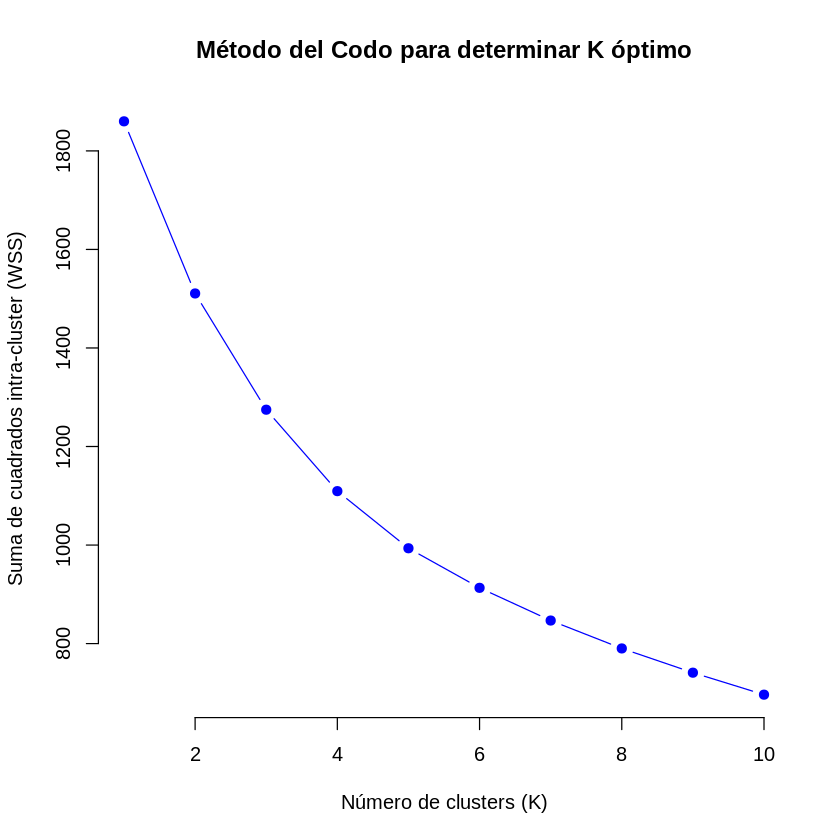

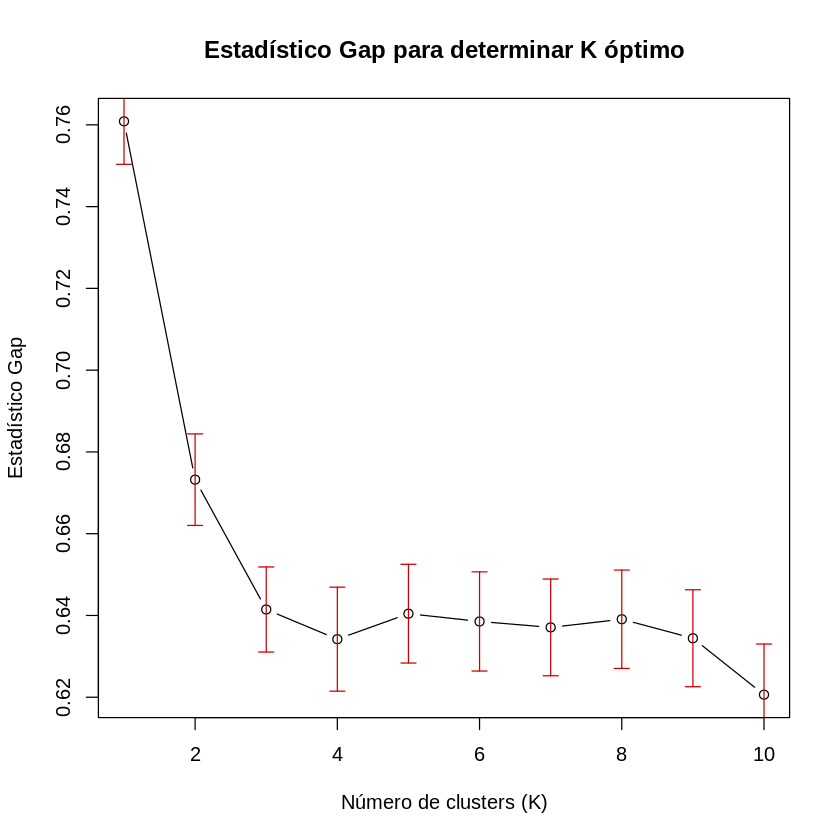

In [ ]:
# Cargar librería cluster
if (!require("cluster")) {
  install.packages("cluster")
  library(cluster)
}

# Método del Codo (WSS)
set.seed(123)
k.max <- 10
# Calculamos la suma de cuadrados intra-cluster (WSS) para k de 1 a 10
wss <- sapply(1:k.max, function(k){
  kmeans(datos_scaled, centers = k, nstart = 25, iter.max = 1000)$tot.withinss
})

# Graficamos el resultado
plot(1:k.max, wss,
     type = "b", pch = 19, frame = FALSE, col = "blue",
     xlab = "Número de clusters (K)",
     ylab = "Suma de cuadrados intra-cluster (WSS)",
     main = "Método del Codo para determinar K óptimo")


# Cálculo y Gráfico del Gap Estadístico
set.seed(123) # Fijar semilla para reproducibilidad
gap_stat <- clusGap(datos_scaled,
                    FUN = kmeans,
                    nstart = 25,
                    K.max = 10,
                    B = 50)

plot(gap_stat,
     main = "Estadístico Gap para determinar K óptimo",
     xlab = "Número de clusters (K)",
     ylab = "Estadístico Gap")

**Análisis del K óptimo:**
* **Gráfico del Método del Codo (WSS)**: Buscando el punto donde la curva hace una "flexión" o codo evidente, indicando que añadir más grupos ya no reduce significativamente la varianza interna de los clusters, este parece situarse entre `4-5`.
* **Gráfico del Estadístico Gap**: Buscando el punto donde la curva alcanza un mínimo local o donde el estadístico deja de crecer de manera pronunciada, este parece situarse en `4`.
* Así, por lo anterior, podríamos considerar `k=4` óptimo.

---

# Ejercicio 2.3

---

## Caracterización de los Grupos Obtenidos

Una vez definido el valor de $K$ (asumiendo $k_0 = 4$), ejecutamos el algoritmo K-means definitivo y analizamos qué características promedio tiene cada cluster.

  Cluster     pm25      no2   trafico   viento
1       1 34.77784 32.03743  52.33730 2.816081
2       2 93.61333 95.65000 119.80833 4.122778
3       3 64.48888 43.83224  67.88092 2.050263
4       4 54.99939 43.83622  63.61615 4.120270


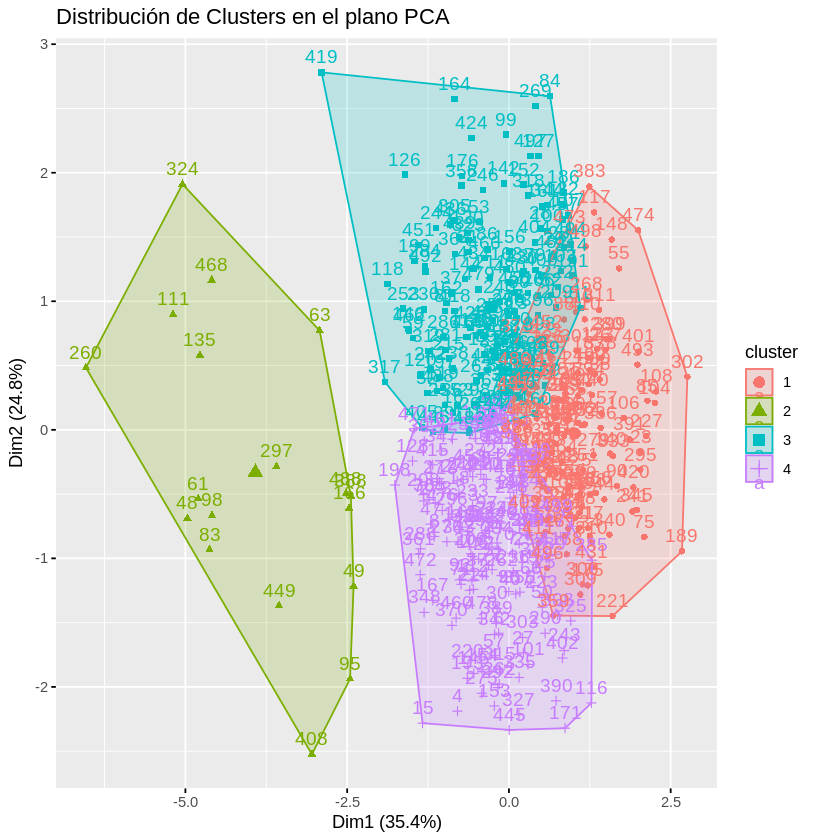

In [ ]:
# Ejecutar K-means con el K optimo
k0 <- 4
set.seed(123)
cl <- kmeans(datos_scaled, centers = k0, iter.max = 1000, nstart = 25)

# Añadir la asignacion del cluster a nuestros datos originales limpios
# (usamos datos_cluster para ver los valores reales, no los escalados)
datos_finales <- data.frame(datos_cluster, Cluster = as.factor(cl$cluster))

# Calcular la media de cada variable segun el grupo asignado
medias_grupos <- aggregate(. ~ Cluster, data = datos_finales, mean)
print(medias_grupos)

# Visualizar los clusters en el plano de componentes principales
fviz_cluster(cl, data = datos_scaled, main = "Distribución de Clusters en el plano PCA")

### Interpretación de los Resultados

Al analizar los centroides (medias) de estos 4 grupos, podemos identificar perfiles muy distintivos de la dinámica ambiental y vehicular:

* **Grupo 1:** _(Condiciones Favorables / Días Limpios)_
    * Los niveles promedio más bajos en todos los contaminantes (**pm25**: 41.05, **no2**: 33.31).### Interpretación de los Resultados

Al analizar los centroides (medias) de estos 4 grupos, podemos identificar perfiles muy distintivos de la dinámica ambiental y vehicular:

* **Grupo 1:** _(Condiciones Favorables / Días Limpios)_
    * Los niveles promedio más bajos en todos los contaminantes (**pm25**: 41.05, **no2**: 33.31).
    * La menor congestión vehicular (**trafico**: 55.93).
    * Apoyado por un nivel de viento relativamente alto (3.19), que favorece la dispersión.
    * Este grupo concentra las mejores condiciones generales.
* **Grupo 2:** _(Contaminación por Partículas / Posible fuente externa)_
    * Un aumento importante en Material Particulado Fino (**pm25**: 76.01).
    * Pero el dióxido de nitrógeno y el tráfico se mantienen en niveles moderados-bajos (46.12 y 65.31 respectivamente).
    * Esto sugiere episodios de contaminación que **no** están directamente causados por vehículos, sino posiblemente por factores estacionales como calefacción a leña o fuentes industriales.
* **Grupo 3:** _(Días de Alta Carga Vehicular)_
    * Este grupo tiene un comportamiento opuesto al Grupo 2.
    * El **pm25** se mantiene bajo/moderado (45.41), pero vemos un aumento considerable en el **no2** (62.06).
    * Un **trafico** pesado (82.72) impulsa el aumento de dióoxido de nitrógeno. Dado que el NO2 está íntimamente ligado a la combustión de los motores, este cluster captura claramente los días laborables de alta congestión y "tacos".
* **Grupo 4:** _(Condiciones Críticas / Alerta Máxima)_
    * Todos los indicadores se disparan simultáneamente
    * Un **pm25** crítico casi en 100 (98.02)
    * Un **no2** altísimo (75.56)
    * Un nivel de **trafico** colapsado (129.58)
    * La velocidad del viento aquí es la más alta en promedio (3.49), lo que indica que las emisiones contaminantes de la ciudad son tan masivas en estos momentos que logran sobreponerse a cualquier capacidad natural de ventilación atmosférica.
    * Al parecer, este cluster agrupa los peores escenarios posibles (los valores extremos o atípicos superiores).
    * La menor congestión vehicular (**trafico**: 55.93).
    * Apoyado por un nivel de viento relativamente alto (3.19), que favorece la dispersión.
    * Este grupo concentra las mejores condiciones generales.
